In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as py

Data Preproceesing

In [30]:
data = pd.read_csv("Housing.csv")
data.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [31]:
data['furnishingstatus'].unique()

array(['furnished', 'semi-furnished', 'unfurnished'], dtype=object)

In [32]:
cols = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]

data[cols] = data[cols].replace({"yes" : 1, "no": 0})

data = pd.get_dummies(data, columns = ["furnishingstatus"])
data = data.astype({"furnishingstatus_furnished" : int,
"furnishingstatus_semi-furnished" : int,
                   "furnishingstatus_unfurnished" : int })
data.head(10)

C:\Users\LOQ\AppData\Local\Temp\ipykernel_19060\2389611940.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[cols] = data[cols].replace({"yes" : 1, "no": 0})


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1,0,0
5,10850000,7500,3,3,1,1,0,1,0,1,2,1,0,1,0
6,10150000,8580,4,3,4,1,0,0,0,1,2,1,0,1,0
7,10150000,16200,5,3,2,1,0,0,0,0,0,0,0,0,1
8,9870000,8100,4,1,2,1,1,1,0,1,2,1,1,0,0
9,9800000,5750,3,2,4,1,1,0,0,1,1,1,0,0,1


Implementing single linear regression

In [33]:
X = data[["area"]] #Using only 2 feaures
y = data["price"]




In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [35]:
from sklearn.linear_model import LinearRegression


model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

r2_score1 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R2:", r2_score1)
print("RMSE:", rmse)



R2: 0.27287851871974644
RMSE: 1917103.7021424233


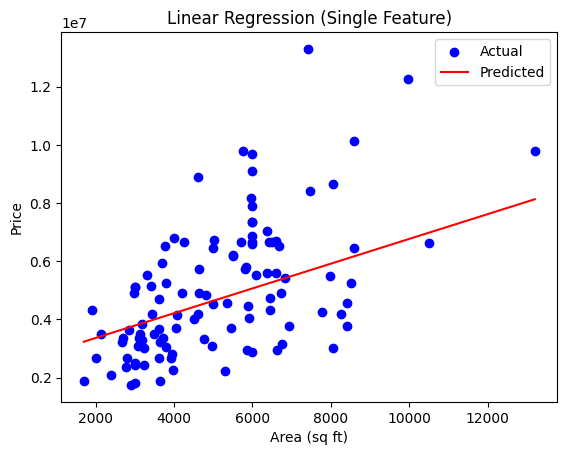

In [37]:
import matplotlib.pyplot as plt

# Scatter plot (actual data)
plt.scatter(X_test, y_test, color='blue', label='Actual')

# Sort values for clean line
sorted_idx = X_test.values.flatten().argsort()
X_sorted = X_test.values.flatten()[sorted_idx]
y_pred_sorted = y_pred[sorted_idx]

# Plot regression line
plt.plot(X_sorted, y_pred_sorted, color='red', label='Predicted')

plt.xlabel("Area (sq ft)")
plt.ylabel("Price")
plt.title("Linear Regression (Single Feature)")
plt.legend()

plt.show()

Implementing multi linear regression with all features of the dataset

In [ ]:
X = data.drop(columns = ['price'])
y = data["price"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
model2 = LinearRegression()
model2.fit(X_train,y_train)
y_pred2 = model2.predict(X_test)

score = r2_score(y_test, y_pred2)
mse2 = mean_squared_error(y_test, y_pred2)
rmse2 = np.sqrt(mse2)
print("R2 score:", score )
print("RMSE:",rmse2)


R2 score: 0.6529242642153185
RMSE: 1324506.9600914384


Using Polynomial Linear Regression

In [ ]:
from sklearn.preprocessing import PolynomialFeatures



X = data.drop("price", axis=1)
y = data["price"]

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)


model = LinearRegression()
model.fit(X_train, y_train)


y_pred3 = model.predict(X_test)
mse3 = mean_squared_error(y_test, y_pred3)
rmse3 = np.sqrt(mse3)

print("R2:", r2_score(y_test, y_pred3))
print("RMSE:", rmse3)

R2: 0.6212800554433078
RMSE: 1383570.223537376


Implemention Linear Regression from scratch

In [ ]:
class LinearRegressionScratch:
    def __init__(self, lr=0.1, epochs=1000):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        m, n = X.shape
        self.w = np.zeros(n)
        self.b = 0

        for _ in range(self.epochs):
            y_pred = np.dot(X, self.w) + self.b

            dw = (1/m) * np.dot(X.T, (y_pred - y))
            db = (1/m) * np.sum(y_pred - y)

            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.w) + self.b

In [ ]:
X = data.drop(columns = ['price'])
y = data['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Scaling was added after encountering NaN values during training.
# Large feature values caused unstable gradient updates, leading to overflow.
# Scaling ensures stable gradient descent and proper convergence.

from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

y_train = scaler_y.fit_transform(y_train.values.reshape(-1,1)).flatten()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1,1)).flatten()

In [ ]:
scratch = LinearRegressionScratch()
scratch.fit(X_train, y_train)

y_pred4 = scratch.predict(X_test)

y_pred4 = scaler_y.inverse_transform(y_pred4.reshape(-1,1)).flatten()

score1 = r2_score(y_test, y_pred4)
mse4 = mean_squared_error(y_test, y_pred4)
rmse4 = np.sqrt(mse4)
print("R2 score:", score1 )
print("RMSE:", rmse4)



R2 score: 0.6529242642153175
RMSE: 1324506.9600914405


Implementing Linear regression by using feature engineering

area                               0.535997
bathrooms                          0.517545
airconditioning                    0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea                           0.329777
mainroad                           0.296898
guestroom                          0.255517
furnishingstatus_furnished         0.229350
basement                           0.187057
hotwaterheating                    0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64


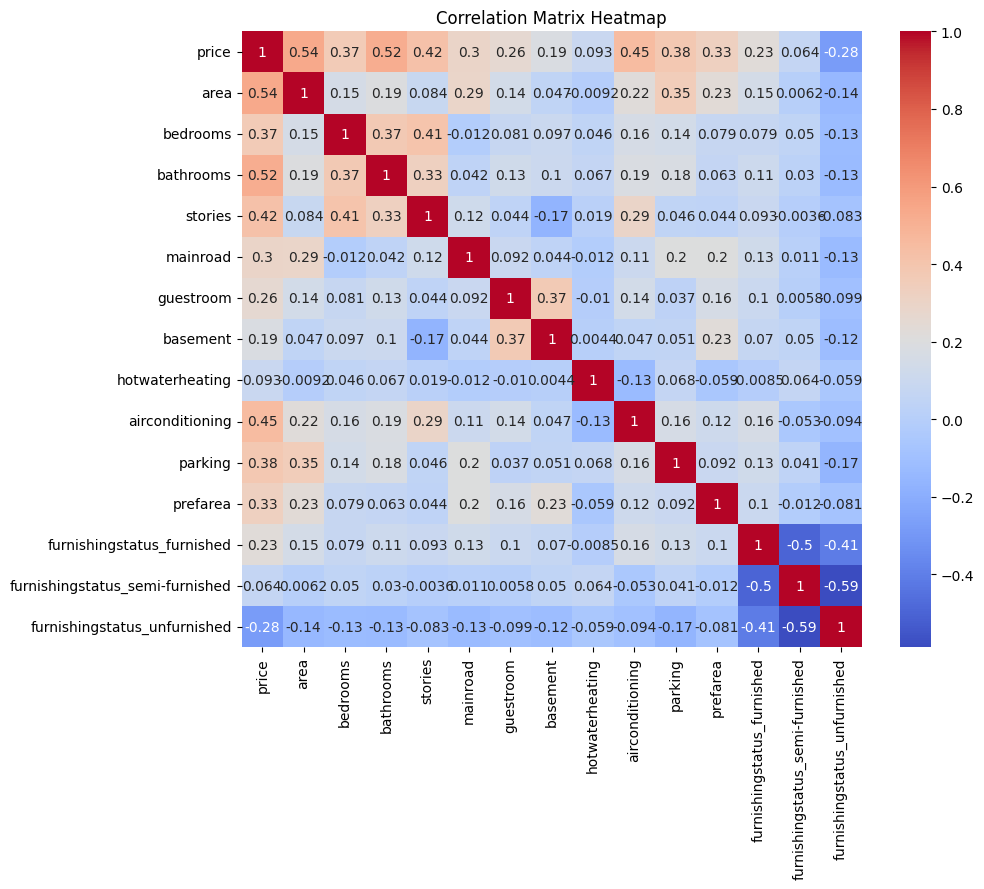

In [ ]:
corr = data.corr(numeric_only=True)

feature_ranking = corr["price"].drop("price").sort_values(ascending=False)

print(feature_ranking)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix Heatmap")
plt.show()

In [ ]:
ranked_features = feature_ranking.index.tolist()
print(ranked_features)

['area', 'bathrooms', 'airconditioning', 'stories', 'parking', 'bedrooms', 'prefarea', 'mainroad', 'guestroom', 'furnishingstatus_furnished', 'basement', 'hotwaterheating', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


In [ ]:
top_k = 3
X = data[ranked_features[:top_k]]
y = data["price"]

In [ ]:


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model5 = LinearRegression()
model5.fit(X_train, y_train)

y_pred5 = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred5)
rmse = np.sqrt(mse)


print("R2:", r2_score(y_test, y_pred5))
print("RMSE:", rmse)

R2: 0.4975067288756453
RMSE: 1593702.4619486341


In [ ]:
for k in range(1, len(ranked_features)+1):
    
    X_k = data[ranked_features[:k]]
    
    X_train, X_test, y_train, y_test = train_test_split(X_k, y, test_size=0.2, random_state=42)
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    
    print(f"Top {k} features → R2: {r2:.4f}")

Top 1 features → R2: 0.2729
Top 2 features → R2: 0.4292
Top 3 features → R2: 0.4975
Top 4 features → R2: 0.5511
Top 5 features → R2: 0.5837
Top 6 features → R2: 0.5886
Top 7 features → R2: 0.6132
Top 8 features → R2: 0.6226
Top 9 features → R2: 0.6317
Top 10 features → R2: 0.6273
Top 11 features → R2: 0.6280
Top 12 features → R2: 0.6420
Top 13 features → R2: 0.6529
Top 14 features → R2: 0.6529
